# `AA Workshop 14` — Coding Challenge

Complete the tasks below to practice text mining techniques from `W14_Textmining.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- transforming text documents to numerical vectors
- implementing classification models based on text data

## Task 1 - Text Classification for Movie Data

Let's practice text mining using a dataset of movie reviews. Your goal is to compute the sentiment (i.e., if text has a positive or negative connotation) of text documents. We will be using Movie Reviews text data from Rotten Tomatoes (https://www.kaggle.com/c/sentiment-analysis-on-movie-reviews/data), which can be found in the data-folder (`movies.tsv`).

Complete the following steps:
- load and understand the data (what is the target?)
- construct bag of words model (tokenization, preprocessing)
- build and evaluate a classification model

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


<Axes: xlabel='Sentiment'>

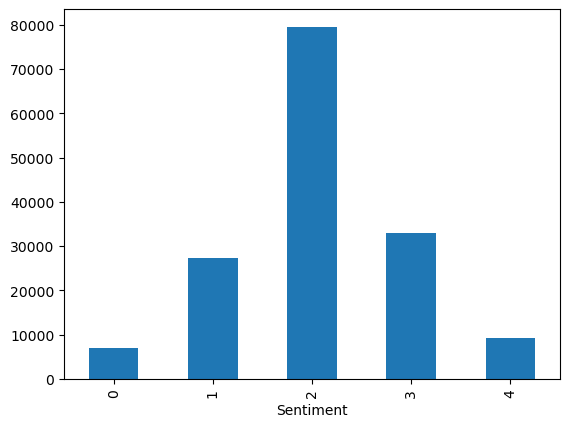

In [12]:
data = pd.read_csv("../data/movies.tsv", sep="\t")
display(data.head())
data["Sentiment"].value_counts().sort_index().plot(kind="bar")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize

cv = CountVectorizer(lowercase=True, stop_words='english', ngram_range=(1,1), tokenizer=word_tokenize)
text_counts = cv.fit_transform(data['Phrase'])

print(text_counts)

/home/timo/miniconda3/envs/AA_env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 642515 stored elements and shape (156060, 16251)>
  Coords	Values
  (0, 12631)	1
  (0, 4851)	1
  (0, 3744)	1
  (0, 396)	1
  (0, 6144)	2
  (0, 6168)	1
  (0, 5903)	1
  (0, 25)	1
  (0, 9799)	1
  (0, 715)	1
  (0, 706)	1
  (0, 13712)	1
  (0, 30)	1
  (1, 12631)	1
  (1, 4851)	1
  (1, 3744)	1
  (1, 396)	1
  (1, 6144)	1
  (1, 6168)	1
  (2, 12631)	1
  (4, 12631)	1
  (5, 4851)	1
  (5, 3744)	1
  (5, 396)	1
  (5, 6144)	1
  :	:
  (156050, 12190)	1
  (156050, 9788)	1
  (156051, 12190)	1
  (156051, 9788)	1
  (156052, 12190)	1
  (156053, 20)	1
  (156053, 1451)	1
  (156053, 5618)	1
  (156053, 6624)	1
  (156053, 1151)	1
  (156053, 2503)	1
  (156054, 20)	1
  (156054, 5618)	1
  (156054, 6624)	1
  (156054, 1151)	1
  (156054, 2503)	1
  (156055, 20)	1
  (156055, 6624)	1
  (156056, 5618)	1
  (156056, 1151)	1
  (156056, 2503)	1
  (156057, 1151)	1
  (156057, 2503)	1
  (156058, 1151)	1
  (156059, 2503)	1


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    text_counts, data['Sentiment'], test_size=0.3)
print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 109242 samples
Test set size: 46818 samples


In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

clf = MultinomialNB()
clf.fit(X_train, y_train)

print("MultinomialNB Accuracy (Train):", metrics.accuracy_score(y_train, clf.predict(X_train)))
print("MultinomialNB Accuracy (Test):", metrics.accuracy_score(y_test, clf.predict(X_test)))

MultinomialNB Accuracy (Train): 0.6791618608227604
MultinomialNB Accuracy (Test): 0.6041693365799479


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf=TfidfVectorizer(lowercase=True,stop_words='english',ngram_range = (1,1),tokenizer = word_tokenize)
text_tf= tf.fit_transform(data['Phrase'])

X_train, X_test, y_train, y_test = train_test_split(
    text_tf, data['Sentiment'], test_size=0.3)

clf = MultinomialNB()
clf.fit(X_train, y_train)
predicted= clf.predict(X_test)

print("MultinomialNB Accuracy (Train):", metrics.accuracy_score(y_train, clf.predict(X_train)))
print("MultinomialNB Accuracy (Test):", metrics.accuracy_score(y_test, clf.predict(X_test)))

/home/timo/miniconda3/envs/AA_env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


MultinomialNB Accuracy (Train): 0.6390216217205836
MultinomialNB Accuracy (Test): 0.5847750865051903


----